# Нейронные сети и глубокое обучение, МНАД ВШЭ

## Домашнее задание 4. Трансформеры.

### Общая информация

### Оценивание и штрафы

Максимально допустимая оценка за работу без бонусов — 10 баллов. Сдавать задание после указанного срока жесткого дедлайна нельзя.

Сдача работы после мягкого дедлайна штрафуется ступенчато, -1 балл в сутки. Один раз за модуль студентам предоставляется возможность использовать отсрочку и сдать в жесткий дедлайн без штрафа.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Использование генеративных моделей допустимо на следующих условиях:
- Количество кода, написанное генеративными моделями, не превышает 30%
- Указана модель, использованная для генерации, а также промпт
- В конце работы необходимо описать свой опыт использования генеративного ИИ для решения данного домашнего задания. Укажите как часто Вам приходилось исправлять код своими руками или просить модель что-то исправить. Было ли это быстрее, чем написать код самим?

В случае невыполнения этих требований работа не оценивается и оценка за неё не превышает 0 баллов.

### О задании

В этой домашней работе вам предстоит добавить к BERT'у декодерную часть и решить задачу написания tl;dr для текстов новостей на русском языке.

Дополнительно к этому на отличную оценку потребуется реализовать менее жадную стратегию выбора следующего токена для генерации.

In [ ]:
!pip install transformers datasets evaluate tensorboard

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.3 MB/s eta 0:00:00


In [16]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, BertModel, BertTokenizer
import evaluate

# Автоматический выбор устройства: GPU при наличии, иначе CPU
try:
    device = "cuda" if torch.cuda.is_available() else "cpu"
except (AssertionError, RuntimeError):
    device = "cpu"  # PyTorch без CUDA
print(f"Using device: {device}")

Using device: cpu


## Подготовка данных (0.5 балла)

Мы воспользуемся датасетом с 🤗 Ильи Гусева "gazeta". Он представляет собой пары (полный текст новости -- его саммари).

Более подробно про датасет можно прочитать [здесь](https://huggingface.co/datasets/IlyaGusev/gazeta)



In [17]:
# Загрузим данные с попощью библиотеки библиотеки datasets
# Вы вольны взять меньше или больше данных, но что-то около адекватное получается обычно только на >=10%

from datasets import load_dataset

dataset = load_dataset("IlyaGusev/gazeta", split="train[:70%]")

Вы должны помнить, что тексты перед подачей в модель необходимо **токенизировать**.

Добавьте паддинг до `max_length=512` для обучающих данных, а также до `max_length=128` для меток.

Используйте обрезку текстов, длина которых в токенах превышает `max_length`

In [18]:
# Подготовим данные для модели Bert

model_name = "deepvk/bert-base-uncased"  # Указание модели BERT

tokenizer = AutoTokenizer.from_pretrained(model_name)


def preprocess(examples, use_padding=True):

    # <YOUR CODE HERE>
    encoder_encoded = tokenizer(
        examples["text"],
        max_length=512,
        padding="max_length",
        truncation=True,
        return_tensors=None,
    )
    decoder_encoded = tokenizer(
        examples["summary"],
        max_length=128,
        padding="max_length",
        truncation=True,
        return_tensors=None,
    )
    model_inputs = {
        "input_ids": encoder_encoded["input_ids"],
        "attention_mask": encoder_encoded["attention_mask"],
        "decoder_input_ids": decoder_encoded["input_ids"],
    }
    return model_inputs

In [19]:
tokenized_dataset = dataset.map(preprocess, batched=False)
tokenized_dataset.set_format("torch")

In [20]:
from torch.utils.data import DataLoader, random_split

n = len(tokenized_dataset)
train_ds, eval_ds = random_split(tokenized_dataset, [int(0.7 * n), n - int(0.7 * n)])
train_dataloader = DataLoader(train_ds, batch_size=16, shuffle=True, drop_last=True)
eval_dataloader = DataLoader(eval_ds, batch_size=16)

## Реализация Decoder-cети (3 балла)

В данном разделе вам необходимо **реализовать собственный декодер для генерации текста**.

Можете вдохновляться кодом с семинара. В инициализации весов стоит (но необязательно) вспомнить нюансы.

In [21]:
import torch
import torch.nn as nn
from transformers import BertModel, BertTokenizer

# Класс модели для суммаризации на основе BERT с кастомным декодером


class BertSummarizer(nn.Module):
    def __init__(
        self,
        bert_model_name="bert-base-uncased",
        hidden_size=768,
        num_decoder_layers=3,
        num_heads=8,
        dropout=0.1,
    ):
        super().__init__()
        self.bert = BertModel.from_pretrained(bert_model_name)
        self.hidden_size = hidden_size

        # Эмбеддинги для токенов на входе в декодер
        self.embedding = nn.Embedding(self.bert.config.vocab_size, hidden_size)

        # <YOUR CODE HERE>
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=hidden_size,
            nhead=num_heads,
            dim_feedforward=hidden_size * 4, #Так сделано в оригинальной статье "Attention is All You Need" и во многих реализациях.!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
            dropout=dropout,
            batch_first=False,
        )
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_decoder_layers)
        self.fc_out = nn.Linear(hidden_size, self.bert.config.vocab_size)

    # Функция для создания маски для предотвращения заглядывания вперед в декодере

    def generate_square_subsequent_mask(self, T):
        # <YOUR CODE HERE>
        return torch.triu(torch.ones(T, T), diagonal=1).bool()

    def forward(self, input_ids, attention_mask, decoder_input_ids):
        encoder_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        memory = (
            encoder_outputs.last_hidden_state
        )  # Выходы BERT для использования в декодере

        # Эмбеддинги для входных токенов декодера
        embedded = self.embedding(decoder_input_ids)

        # <YOUR CODE HERE>
        tgt = embedded.transpose(0, 1)
        memory_t = memory.transpose(0, 1)
        T = tgt.size(0)
        tgt_mask = self.generate_square_subsequent_mask(T).to(embedded.device)
        decoder_output = self.decoder(tgt, memory_t, tgt_mask=tgt_mask)
        output = self.fc_out(decoder_output.transpose(0, 1))# change this line

        return output

    def generate(self, input_ids, attention_mask, tokenizer, max_len=50):
        encoder_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        memory = encoder_outputs.last_hidden_state
        batch_size = input_ids.size(0)

        # Начинаем с токена [CLS] или [BOS] (начало последовательности)
        decoder_input_ids = torch.full(
            (batch_size, 1), tokenizer.cls_token_id, dtype=torch.long
        ).to(input_ids.device)
        memory = memory.transpose(0, 1)
        generated_tokens = []

        for _ in range(max_len):
            embedded = self.embedding(decoder_input_ids).transpose(0, 1)

            # Генерация маски для предотвращения заглядывания вперед
            decoder_attention_mask = self.generate_square_subsequent_mask(
                embedded.size(0)
            ).to(input_ids.device)
            decoder_output = self.decoder(
                tgt=embedded, memory=memory, tgt_mask=decoder_attention_mask
            )

            output = self.fc_out(decoder_output.transpose(0, 1))

            # Получаем индекс токена с наибольшей вероятностью.
            # Помните, если EOS предсказан, прекращаем генерацию

            # <YOUR CODE HERE>
            next_token = output[:, -1, :].argmax(dim=-1, keepdim=True)
            decoder_input_ids = torch.cat([decoder_input_ids, next_token], dim=1)
            eos_id = tokenizer.sep_token_id or tokenizer.eos_token_id
            if eos_id is not None and (next_token == eos_id).all():
                break

        generated_sequence = tokenizer.decode(
            decoder_input_ids.squeeze().tolist(), skip_special_tokens=True
        )

        return generated_sequence

In [22]:
# Инициализируем нашу модель и посморим на ее архитектруру


model = BertSummarizer(bert_model_name=model_name)
model = model.to(device)
model

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: deepvk/bert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertSummarizer(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(36000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_af

In [23]:
# Посмотрим на генерацию без обучения

eval_data_sample = next(iter(eval_dataloader))
model.generate(
    eval_data_sample["input_ids"][:1].to(device),
    eval_data_sample["attention_mask"][:1].to(device),
    tokenizer,
)

'пришел основакин пep нали завтрак эго якии индивидуальныи призвал способ письма учимсятии состо photo солнц учебу представи сказали платежныеганы ожидая отменить изменится убиицу эго неулови поместье финансовои марка комок выпускнои volчивое смотрели машиностическои однозна проверка хранитсядал бедторин дес ощутила приблизился внезапно кошек █║►'

## Обучение модели (1 балл)

0.25 балла за простейший рабочий цикл;

0.5 балла за графики для лосса и метрик на трейне и валидации.

0.25 балла за логгинг в тензорборд или WandB

В данном разделе вам необходимо **реализовать цикл для обучения модели**


In [24]:
# Пример обучения на одной итерации
# Все помнят, что надо предсказывать следующий токен?


def train_step(
    model, input_ids, attention_mask, decoder_input_ids, optimizer, criterion
):
    model.train()
    optimizer.zero_grad()
    outputs = model(input_ids, attention_mask, decoder_input_ids)
    loss = criterion(outputs.view(-1, outputs.size(-1)), decoder_input_ids.view(-1))
    loss.backward()
    optimizer.step()

    return loss.item()

In [26]:
# Полный цикл обучения (1 балл: цикл + TensorBoard + сохранение лучшей модели)
from tqdm import tqdm
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt

device = next(model.parameters()).device
criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id or 0, label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.05)
save_path = "best_bert_summarizer.pt"
best_eval = float("inf")
history_train, history_eval = [], []
writer = SummaryWriter(log_dir="runs/bert_summarizer")
max_epochs = 10
patience = 2  # останов, если eval не улучшался 2 эпохи подряд
epochs_no_improve = 0

for epoch in range(max_epochs):
    model.train()
    train_losses = []
    for b in tqdm(train_dataloader, desc=f"Epoch {epoch+1} train"):
        train_losses.append(train_step(model, b["input_ids"].to(device), b["attention_mask"].to(device), b["decoder_input_ids"].to(device), optimizer, criterion))
    mean_train = sum(train_losses) / len(train_losses)

    model.eval()
    eval_losses = []
    with torch.no_grad():
        for b in tqdm(eval_dataloader, desc=f"Epoch {epoch+1} eval"):
            dec = b["decoder_input_ids"].to(device)
            decoder_inp = dec[:, :-1]
            labels = dec[:, 1:]
            out = model(b["input_ids"].to(device), b["attention_mask"].to(device), decoder_inp)
            eval_losses.append(criterion(out.reshape(-1, out.size(-1)), labels.reshape(-1)).item())
    mean_eval = sum(eval_losses) / len(eval_losses)

    history_train.append(mean_train)
    history_eval.append(mean_eval)
    writer.add_scalar("Loss/train", mean_train, epoch + 1)
    writer.add_scalar("Loss/eval", mean_eval, epoch + 1)

    if mean_eval < best_eval:
        best_eval = mean_eval
        epochs_no_improve = 0
        torch.save({"model_state_dict": model.state_dict()}, save_path)
    else:
        epochs_no_improve += 1
    print(f"Epoch {epoch+1}: train={mean_train:.4f}, eval={mean_eval:.4f}")
    if epochs_no_improve >= patience:
        print(f"Early stopping: eval не улучшался {patience} эпох. Лучшая модель сохранена (eval={best_eval:.4f}).")
        break

writer.close()

ModuleNotFoundError: No module named 'tensorboard'

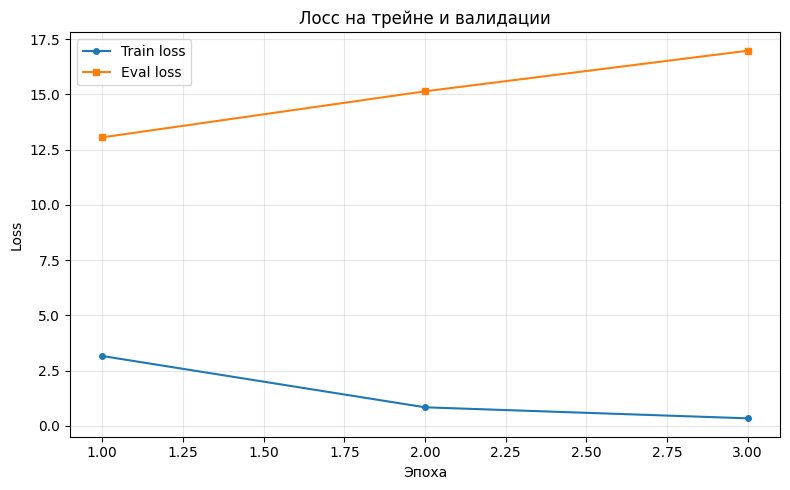

In [ ]:
# Графики лосса на трейне и валидации (1 балл — 0.5 за графики)
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(history_train) + 1), history_train, label="Train loss", marker="o", markersize=4)
plt.plot(range(1, len(history_eval) + 1), history_eval, label="Eval loss", marker="s", markersize=4)
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.legend()
plt.title("Лосс на трейне и валидации")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Метрики качества (1 балл)

По 0.33 балла за измерение каждой из предлагаемых метрик

**Реализуйте функицию для подсчета метрик качества суммаризации.**

Что мы хотим считать:
 1. [HuggingFace Rouge](https://huggingface.co/spaces/evaluate-metric/rouge)
 2. [HuggingFace Bleu](https://huggingface.co/spaces/evaluate-metric/bleu)
 3. [HuggingFace BERT Score](https://huggingface.co/spaces/evaluate-metric/bertscore)

In [ ]:
def compute_metrics(predictions, references):
    # <YOUR CODE HERE>
    rouge = evaluate.load("rouge")
    bleu = evaluate.load("bleu")
    bertscore = evaluate.load("bertscore")

    r = rouge.compute(predictions=predictions, references=references)
    b = bleu.compute(predictions=predictions, references=[[ref] for ref in references])
    bert = bertscore.compute(predictions=predictions, references=references, lang="ru")

    f1_list = bert["f1"]
    bert_f1 = sum(f1_list) / len(f1_list)

    return {"rouge1": r["rouge1"], "rouge2": r["rouge2"], "bleu": b["bleu"], "bertscore_f1": bert_f1}


def evaluation(model, eval_dataloader, tokenizer, device):
    # <YOUR CODE HERE>
    model.eval()
    predictions = []
    references = []
    with torch.no_grad():
        for batch in eval_dataloader:
            inp = batch["input_ids"].to(device)
            attn = batch["attention_mask"].to(device)
            for j in range(inp.size(0)):
                pred = model.generate(inp[j : j + 1], attn[j : j + 1], tokenizer)
                predictions.append(pred)
                ref = tokenizer.decode(batch["decoder_input_ids"][j].tolist(), skip_special_tokens=True)
                references.append(ref)
    return compute_metrics(predictions, references)

## Обучение модели (0.5 балла)
**Обучите модель, сохраните лучшую версию** (метод `.save_pretrained()` объекта класса AutoModel... или `torch.save()`) **и добавьте пример генерации**. Учтите, что если изменялся токенизатор (а лучше просто по умолчанию), его тоже нужно сохранить.

Для сравнения оценки качества генерации по значениям реализованных метрик можете запустить ruT5-small без дообучения. Мы намеренно даем бейзлайн именно в таком виде.

In [ ]:
checkpoint = torch.load(save_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
tokenizer.save_pretrained("best_bert_summarizer")

sample = next(iter(eval_dataloader))
pred = model.generate(
    sample["input_ids"][:1].to(device),
    sample["attention_mask"][:1].to(device),
    tokenizer,
)
# Эталонное саммари (для сравнения)
ref_summary = tokenizer.decode(sample["decoder_input_ids"][0].tolist(), skip_special_tokens=True)
print("Эталон (reference):", ref_summary[:200] + ("..." if len(ref_summary) > 200 else ""))
print("Пример генерации:", pred if pred.strip() else "(пусто)")
if not pred.strip():
    print("(Пустой вывод обычно значит, что модель генерирует только [CLS]/[PAD]; сохранён лучший чекпоинт по eval loss — часто это 1-я эпоха.)")

Эталон (reference): россиискии нападающии « питтсбурга » евгении малкин помог своему клубу одержать победу над « ванкувером », сделав голевую передачу и реализовав послематчевыи буллит. успешно сыграл и вратарь « филадел...
Пример генерации: (пусто)
(Пустой вывод обычно значит, что модель генерирует только [CLS]/[PAD]; сохранён лучший чекпоинт по eval loss — часто это 1-я эпоха.)


In [ ]:
from transformers import AutoModelForSeq2SeqLM

t5_name = "cointegrated/rut5-small"
t5_tokenizer = AutoTokenizer.from_pretrained(t5_name)
t5_model = AutoModelForSeq2SeqLM.from_pretrained(t5_name).to(device)

predictions_t5 = []
references_t5 = []
# На CPU используем 50 примеров для ускорения (полный датасет — часы)
n_eval = min(50, len(eval_ds)) if device == "cpu" else len(eval_ds)
for i in tqdm(range(n_eval), desc="ruT5 генерация"):
    row = eval_ds[i]
    text = row["text"]
    ref = row["summary"]
    inp = t5_tokenizer(text, return_tensors="pt", max_length=512, truncation=True).to(device)
    out = t5_model.generate(**inp, max_length=128)
    pred = t5_tokenizer.decode(out[0], skip_special_tokens=True)
    predictions_t5.append(pred)
    references_t5.append(ref)

metrics_t5 = compute_metrics(predictions_t5, references_t5)
print("ruT5-small (без дообучения):", metrics_t5)
summary = predictions_t5[0]
print("Пример summary (ruT5):", summary)
print("Пример summary (ruT5):", summary)

config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/640k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/98.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/259M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


KeyboardInterrupt: 

In [ ]:
model = AutoModelForSeq2SeqLM.from_pretrained("YOUR MODEL")
summary = #<YOUR CODE HERE>

## Реализация менее жадных стратегий выбора следующего токена (4 балла)
Всегда ли выбор наиболее вероятного токена на каждом шаге – это лучшая стратегия для генерации текста?

<details>
    <summary>Спойлер</summary>
    <p>Нет</p>
</details>

**Сравнение стратегий для генерации текста:**

| Strategy | Description | Pros & Cons |
| --- | --- | --- |
| Greedy Search | Chooses the word with the highest probability as the next word in the sequence. | **Pros:** Simple and fast. <br><br/> **Cons:** Can lead to repetitive and incoherent text. |
| Sampling with Temperature | Introduces randomness in the word selection. A higher temperature leads to more randomness. | **Pros:** Allows exploration and diverse output. <br><br/> **Cons:** Higher temperatures can lead to nonsensical outputs. |
| Nucleus Sampling (Top-p Sampling) | Selects the next word from a truncated vocabulary, the "nucleus" of words <br/> that have a cumulative probability exceeding a pre-specified threshold (p). | **Pros:** Balances diversity and quality. <br><br/> **Cons:** Setting an optimal 'p' can be tricky. |
| Beam Search | Explores multiple hypotheses (sequences of words) at each step, and keeps <br/> the 'k' most likely, where 'k' is the beam width. | **Pros:** Produces more reliable results than greedy search. <br><br/> **Cons:** Can lack diversity and lead to generic responses. |
| Top-k Sampling | Randomly selects the next word from the top 'k' words with the highest probabilities. | **Pros:** Introduces randomness, increasing output diversity. <br><br/> **Cons:** Random selection can sometimes lead to less coherent outputs. |
| Length Normalization | Prevents the model from favoring shorter sequences by dividing the log probabilities <br/> by the sequence length raised to some power. | **Pros:** Makes longer and potentially more informative sequences more likely. <br><br/> **Cons:** Tuning the normalization factor can be difficult. |
| Stochastic Beam Search | Introduces randomness into the selection process of the 'k' hypotheses in beam search. | **Pros:** Increases diversity in the generated text. <br><br/> **Cons:** The trade-off between diversity and quality can be tricky to manage. |
| Decoding with Minimum Bayes Risk (MBR) | Chooses the hypothesis (out of many) that minimizes expected loss under a loss function. | **Pros:** Optimizes the output according to a specific loss function. <br><br/> **Cons:** Computationally more complex and requires a good loss function. |

Ссылки на докуметацию:
- [reference for `AutoModelForCausalLM.generate()`](https://huggingface.co/docs/transformers/v4.29.1/en/main_classes/text_generation#transformers.GenerationMixin.generate)
- [reference for `AutoTokenizer.decode()`](https://huggingface.co/docs/transformers/main_classes/tokenizer#transformers.PreTrainedTokenizer.decode)
- Huggingface [docs on generation strategies](https://huggingface.co/docs/transformers/generation_strategies)

**1. Реализуйте стратегию Top-k в методе `generate`** (1 балл).   

**2. Реализуйте стратегию Nucleus Sampling (Top-p) в методе `generate`** (1 балл)

**3. Реализуйте стратегию Beam Search** (2 балла)

Получилось ли улучшить генерацию?

## Бонус (1 балл)

Что требуется сделать:

- от имеющейся модели "откусить" только декодерную часть
- написать цикл обучения (скорее поправить имеющийся) и дообучить декодер
- посмотреть качество генерации по метрикам и "глазами"
- ответить на вопрос "Дает ли применение Encoder-Decoder архитектуры значительный буст в качестве генерации?" с пруфами